# Session 5 — PySpark Fundamentals

**Modern Data Engineering Course · Week 3 · Session 1 of 2**
*Instructor: Ameer Ul Islam ~ Depthware*

---

## What you'll learn today

By the end of this session, you'll be able to:

1. **Explain why Spark exists** — when Pandas hits its limits and why distributed computing matters
2. **Describe Spark's architecture** — drivers, executors, partitions, and how a cluster splits work
3. **Set up PySpark in local mode** — install it, build a SparkSession, run distributed code on your laptop
4. **Work with Spark DataFrames** — read CSVs, define schemas, inspect data, and write Parquet

This entire notebook is your teaching material **and** your reference. Every code cell is runnable. Run them as we go.

> 💡 **How to use this notebook:** Read the markdown narrative, then run the code cell below it. Don't skip the exercises — they're where the learning sticks.


## 1. The Pandas Wall

Meet **Rahim**, a junior data analyst at a Dhaka-based ride-share company. His Pandas script worked beautifully on 100,000 rides. Then the company grew. Now he needs to analyze 50 million rides from the past year — and his laptop just refuses.

Here's what he sees in his terminal:

```text
$ python analyze_rides.py
Loading 50,000,000 rows from rides_2024.csv...
Traceback (most recent call last):
  File "analyze_rides.py", line 4, in <module>
    df = pd.read_csv('rides_2024.csv')
MemoryError: Unable to allocate 12.4 GiB for an array with shape (50000000, 8)
```

### Why does this happen?

Pandas loads the entire dataset into RAM. Rahim's laptop has 8 GB of RAM. The dataset needs 12.4 GB. Game over.

This is the **Pandas Wall** — the moment every data person eventually hits.

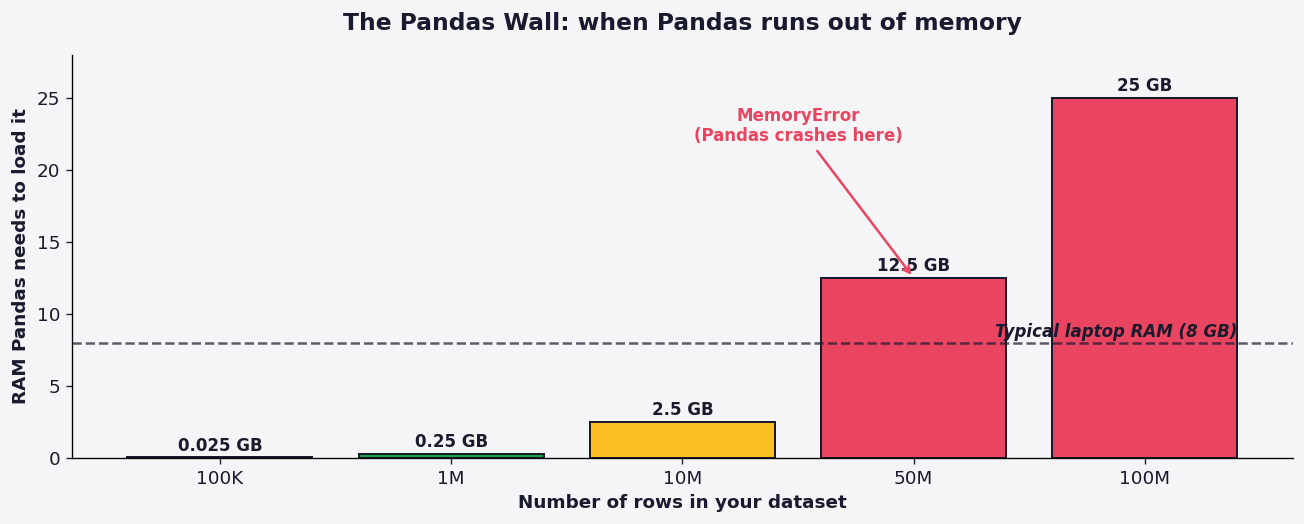

**Takeaway:** Pandas is excellent for data that fits in your RAM. The problem is that "big data" — the kind that drives modern companies — almost never fits.


## 2. Two ways to handle bigger data

When your data outgrows your laptop, you have exactly two options.

### Option A — Vertical scaling: buy a bigger laptop

Get a machine with 64 GB of RAM. Then 128. Then 256. Hardware costs grow exponentially, and eventually no single machine is big enough. This is a dead-end for serious data work.

### Option B — Horizontal scaling: use many laptops together

Instead of one expensive monster machine, network together 8 cheap ones. Split the data across them. Have each one process its piece. Combine the results.

This is what **Spark** does.

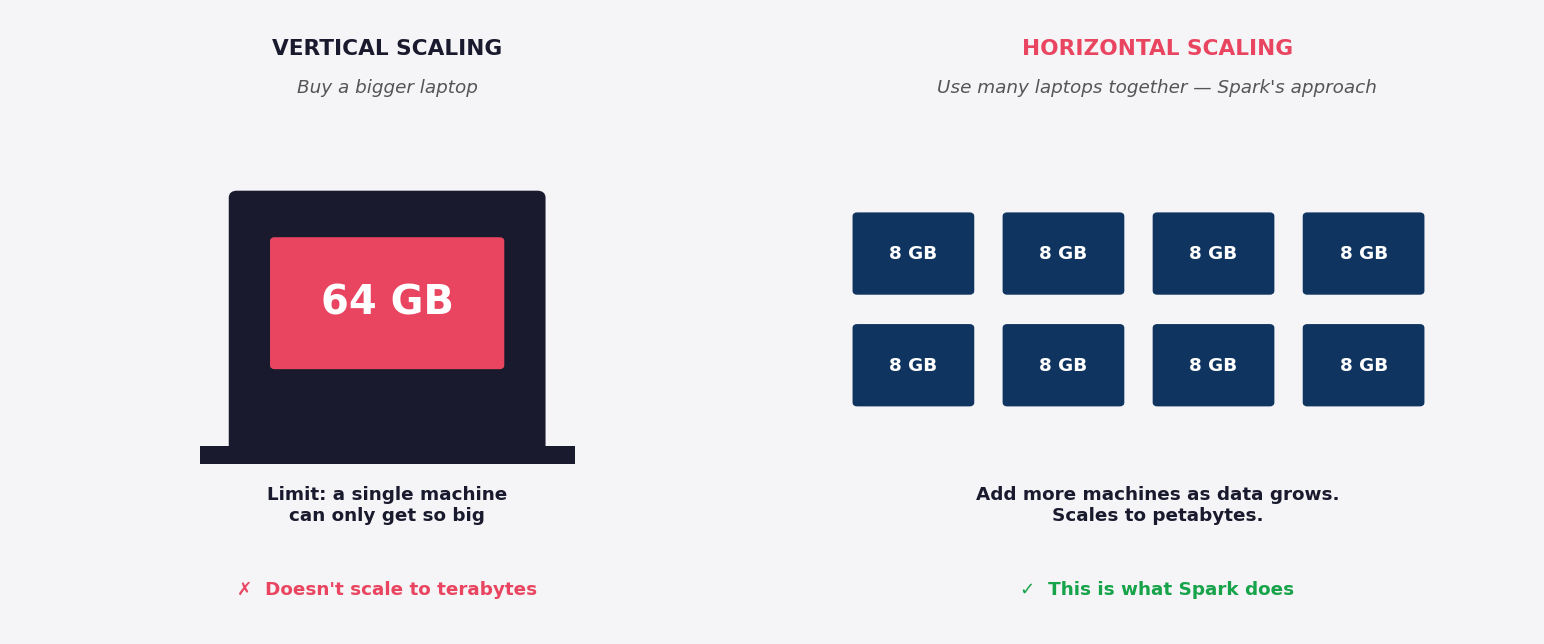

> 🔑 **The key insight:** horizontal scaling is the only approach that scales to terabytes and petabytes. Every modern data system — Spark, BigQuery, Snowflake, Hadoop — works this way.


## 3. Enter Apache Spark

**Apache Spark** is the engine that processes data across hundreds — even thousands — of machines, in parallel.

A few key facts:

- **Born at UC Berkeley's AMPLab in 2009** to be 100x faster than Hadoop MapReduce. Now an Apache top-level project with thousands of contributors worldwide.
- **Built for speed.** Processes data in memory across many machines. Includes libraries for SQL, streaming, machine learning, and graph processing — all in one engine.
- **Industry standard.** Used by Netflix, Uber, Airbnb, Pinterest, Shopify, and most major banks. If a company processes large data, they almost certainly use Spark somewhere.

This is the tool that takes Rahim from *"my laptop crashed"* to *"50 million rides analyzed in 2 minutes."*


## 4. Spark's architecture: a restaurant kitchen

Spark splits work into a **driver** and many **executors**. The clearest way to understand them is the kitchen analogy.

![Spark architecture](viz_architecture.png)

## 5. Partitions — how Spark splits the work

The magic of Spark is **partitioning**: a big dataset gets sliced into many small chunks, and each chunk gets processed independently and in parallel.

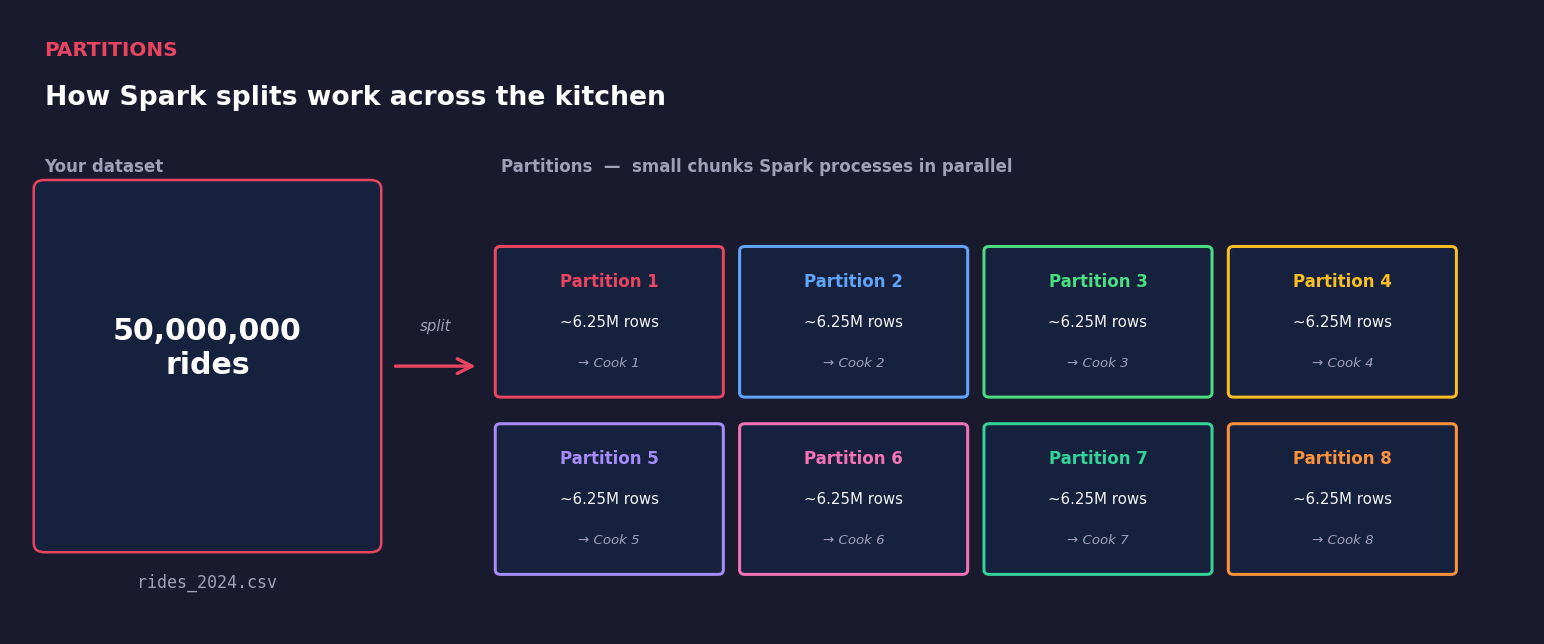

A few key points about partitions:

- **Each partition is a unit of parallelism.** If you have 8 partitions and 4 executor cores, 4 partitions are processed simultaneously while 4 wait their turn.
- **Spark decides the partition count automatically** based on the file size and your cluster. You can override it (we'll see how in Session 6).
- **Partitions live on different machines** in a real cluster. In local mode, they're processed by different threads on your laptop.

> 🔑 **Key insight:** the more evenly your data is partitioned, the better Spark performs. Uneven partitions (one huge, others tiny) cause "skew" — a topic for a later session.


## 6. Local mode: Spark on your laptop

Here's the good news: **you don't need a real cluster to learn Spark.**

In **local mode**, Spark simulates a cluster on a single machine. The driver runs as one Python process. Executors are simulated as threads using your CPU cores. The same API, the same code, the same DataFrames — just running on one machine instead of many.

| What you get | What you don't |
|---|---|
| ✓ Same API as production | ✗ No real distribution |
| ✓ Real parallelism (uses all your CPU cores) | ✗ Limited by your RAM |
| ✓ Free, easy, instant | ✗ Can't see the Spark UI for a real cluster |

> 💡 **Today's plan:** you'll run all the code below in local mode. Later in this session, I'll switch over to a **Databricks Free Edition** browser tab and we'll watch a job run on a real (small) cluster — so you see what the real thing looks like.


## 7. Setup: install PySpark

Before we write any Spark code, we need three things installed:

1. **Java 8 or 11** (Spark runs on the JVM under the hood). Don't use Java 17+ — many Spark builds aren't compatible yet.
2. **Python 3.8+** (you already have this from earlier sessions).
3. **PySpark** itself (the Python library that talks to Spark).

In your terminal, run:

```bash
# Check Java version (should be 8 or 11)
java -version

# Install PySpark
pip install pyspark==3.5.0

# Verify
python -c "import pyspark; print(pyspark.__version__)"
```

> ⚠️ **Common setup hiccups:**
> - **No Java?** Install OpenJDK 11. On Mac: `brew install openjdk@11`. On Ubuntu: `sudo apt install openjdk-11-jdk`.
> - **JAVA_HOME not set?** Spark will throw cryptic errors on startup. Set it explicitly in your shell config.
> - **Windows users:** you'll need `winutils.exe` in `HADOOP_HOME`. We'll walk through this in office hours if you hit it.
> - **Use a virtual environment.** We'll cover venvs formally in Session 14, but for now: `python -m venv pandas_venv && source pandas_venv/bin/activate` is your friend.

Once installed, the cell below should run without errors:


In [17]:
# Verify PySpark is installed and importable
import pyspark
print(f"PySpark version: {pyspark.__version__}")


PySpark version: 3.5.4


## 8. Your first SparkSession

The **SparkSession** is your entry point to Spark — like `pd.read_csv` was for Pandas. Every Spark program starts by building one.


In [22]:
from pyspark.sql import SparkSession

# Build a SparkSession in local mode
spark = (
    SparkSession.builder
        .appName("FirstSparkApp")    # name shows up in the Spark UI
        .master("local[4]")          # use all available CPU cores
        .getOrCreate()               # reuse existing session if there is one
)

# Confirm it's alive
print(f"Spark version  : {spark.version}")
print(f"Master         : {spark.sparkContext.master}")
print(f"Application ID : {spark.sparkContext.applicationId}")


Spark version  : 3.5.4
Master         : local[*]
Application ID : local-1778851749114


### What just happened

| Piece | What it does |
|---|---|
| `appName(...)` | A friendly name that appears in the Spark UI. Always make it descriptive. |
| `master("local[*]")` | Tells Spark where to run. `local[*]` means "this machine, use all CPU cores." `local[4]` would mean 4 cores. In production, this would be a cluster URL. |
| `getOrCreate()` | Reuses an existing SparkSession if one's already running, otherwise builds a new one. Always use this — never `Builder().build()` directly. |

> 💡 **First time you run this:** Spark takes 5–10 seconds to warm up. That's normal — it's spinning up the JVM and the local executors.


## 9. Spark DataFrame vs Pandas DataFrame

Same shape, very different engine underneath.

| | **Pandas DataFrame** | **Spark DataFrame** |
|---|---|---|
| Where it lives | Single machine's RAM | Distributed across many nodes |
| Size limit | Limited by your laptop RAM (a few GBs) | Petabytes — really |
| Execution | Eager — runs immediately | Lazy — waits to optimize (Session 6!) |
| Best for | Exploration, small-medium data | Production pipelines, big data |

**Good news:** if you know Pandas, 70% of Spark feels familiar. The other 30% is what makes it scale.


## 10. Creating your first Spark DataFrame

The simplest way to make a Spark DataFrame is from a Python list — useful for quick experimentation and tests.


In [23]:
# A small list of Dhaka ride records
rides = [
    ("R001", "Rahim",  "Dhanmondi",  "Gulshan",     320, "completed"),
    ("R002", "Karim",  "Mirpur",     "Banani",      280, "completed"),
    ("R003", "Fatima", "Uttara",     "Motijheel",   540, "cancelled"),
    ("R004", "Ayesha", "Mohakhali",  "Bashundhara", 410, "completed"),
]

columns = ["ride_id", "rider", "pickup", "dropoff", "fare_bdt", "status"]

# createDataFrame turns Python data into a Spark DataFrame
df = spark.createDataFrame(rides, columns)

# Show the result
df.show()


+-------+------+---------+-----------+--------+---------+
|ride_id| rider|   pickup|    dropoff|fare_bdt|   status|
+-------+------+---------+-----------+--------+---------+
|   R001| Rahim|Dhanmondi|    Gulshan|     320|completed|
|   R002| Karim|   Mirpur|     Banani|     280|completed|
|   R003|Fatima|   Uttara|  Motijheel|     540|cancelled|
|   R004|Ayesha|Mohakhali|Bashundhara|     410|completed|
+-------+------+---------+-----------+--------+---------+



You should see a 4-row table printed in the output above. **That's your first Spark DataFrame** — congratulations.

Notice how `.show()` formats it with a clean ASCII table. This is intentionally different from Pandas' HTML rendering — Spark assumes you might be running on a remote cluster with no display.


## 11. Reading a CSV file

Inline lists are great for tests, but real data lives in files. Let's read a CSV.

We've provided a sample file `dhaka_rides.csv` (500 rows of synthetic ride data) alongside this notebook. Run the cell below to load it.


In [4]:
# The simplest read — just give Spark a path
df_basic = spark.read.csv("dhaka_rides.csv")
print("WITHOUT header=True (column names are wrong):")
df_basic.show(3)


WITHOUT header=True (column names are wrong):
+-------+-----+--------+-------+--------+---------+----------+
|    _c0|  _c1|     _c2|    _c3|     _c4|      _c5|       _c6|
+-------+-----+--------+-------+--------+---------+----------+
|ride_id|rider|  pickup|dropoff|fare_bdt|   status| ride_date|
|  R0001|Rahim|Farmgate|Gulshan|  650.99|completed|2024-01-29|
|  R0002|Layla|  Banani|Gulshan|  146.94|completed|2024-01-05|
+-------+-----+--------+-------+--------+---------+----------+
only showing top 3 rows



Notice the columns are named `_c0`, `_c1`, `_c2`... and the actual header row got loaded as data. Not what we want.

Let's tell Spark the first row is a header:


In [4]:
# Better: tell Spark there's a header row
df_with_header = spark.read.csv("dhaka_rides.csv", header=True)
print("WITH header=True (correct names, but all columns are strings):")
df_with_header.show(3)
df_with_header.printSchema()


WITH header=True (correct names, but all columns are strings):
+-------+-----+---------+-------+--------+---------+----------+
|ride_id|rider|   pickup|dropoff|fare_bdt|   status| ride_date|
+-------+-----+---------+-------+--------+---------+----------+
|  R0001|Rahim| Farmgate|Gulshan|  650.99|completed|2024-01-29|
|  R0002|Layla|   Banani|Gulshan|  146.94|completed|2024-01-05|
|  R0003|Tariq|Dhanmondi| Banani|  259.15|cancelled|2024-01-04|
+-------+-----+---------+-------+--------+---------+----------+
only showing top 3 rows

root
 |-- ride_id: string (nullable = true)
 |-- rider: string (nullable = true)
 |-- pickup: string (nullable = true)
 |-- dropoff: string (nullable = true)
 |-- fare_bdt: string (nullable = true)
 |-- status: string (nullable = true)
 |-- ride_date: string (nullable = true)



Now the column names are right, but **every column is `string`** — including `fare_bdt`, which should be numeric. Spark can't tell types from a CSV without doing extra work.

We have two choices: ask Spark to guess (`inferSchema=True`), or tell Spark exactly what we want (an explicit schema). Both work; one is much better for production.


In [5]:
# Option 1: ask Spark to infer types
# WARNING: Spark will read the file twice — once to figure out types, once to load data
df_inferred = spark.read.csv("dhaka_rides.csv", header=True, inferSchema=True)
print("WITH inferSchema=True (types are correct now):")
df_inferred.printSchema()


WITH inferSchema=True (types are correct now):
root
 |-- ride_id: string (nullable = true)
 |-- rider: string (nullable = true)
 |-- pickup: string (nullable = true)
 |-- dropoff: string (nullable = true)
 |-- fare_bdt: double (nullable = true)
 |-- status: string (nullable = true)
 |-- ride_date: date (nullable = true)



## 12. Schemas: explicit beats inferred

`inferSchema=True` is convenient for exploration, but it has real costs that bite you in production.

| | `inferSchema=True` | Explicit schema |
|---|---|---|
| Reads file how many times? | **Twice** (one pass to guess types, one to load) | **Once** |
| Type guesses can be wrong? | Yes (especially on edge cases) | No — types are guaranteed |
| Documents your data? | No | Yes — schema is your contract |
| Fails loudly on bad data? | No, silently coerces | Yes |

**Rule of thumb:**
- `inferSchema=True` is fine for quick exploration on small files.
- For any pipeline that runs more than once, **always write the schema explicitly.**

Here's how:


In [24]:
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, DateType
)

# A schema is a list of (column_name, type, nullable?) entries
rides_schema = StructType([
    StructField("ride_id",   StringType(),  False),  # never null
    StructField("rider",     StringType(),  True),   # might be null
    StructField("pickup",    StringType(),  True),
    StructField("dropoff",   StringType(),  True),
    StructField("fare_bdt",  DoubleType(),  True),
    StructField("status",    StringType(),  True),
    StructField("ride_date", DateType(),    True),
])

# Use the schema instead of inferSchema=True
df = (
    spark.read
        .option("header", True)
        .schema(rides_schema)        # ← faster + safer
        .csv("dhaka_rides.csv")
)

df.printSchema()
df.show(5)


root
 |-- ride_id: string (nullable = true)
 |-- rider: string (nullable = true)
 |-- pickup: string (nullable = true)
 |-- dropoff: string (nullable = true)
 |-- fare_bdt: double (nullable = true)
 |-- status: string (nullable = true)
 |-- ride_date: date (nullable = true)

+-------+------+--------------------+---------+--------+---------+----------+
|ride_id| rider|              pickup|  dropoff|fare_bdt|   status| ride_date|
+-------+------+--------------------+---------+--------+---------+----------+
|  R0001| Rahim|FarmgateFarmgateF...|  Gulshan|  650.99|completed|2024-01-29|
|  R0002| Layla|              Banani|  Gulshan|  146.94|completed|2024-01-05|
|  R0003| Tariq|           Dhanmondi|   Banani|  259.15|cancelled|2024-01-04|
|  R0004| Layla|           Old Dhaka|   Mirpur|  403.03|completed|2024-03-16|
|  R0005|Zainab|              Uttara|Dhanmondi|  617.57|completed|2024-02-05|
+-------+------+--------------------+---------+--------+---------+----------+
only showing top 5 row

Now the types are exactly what you specified. No guessing, no double-reading. **This is the production pattern.**


---

## 🛠️ Exercise 1 — Your first PySpark session

**Goal:** Practice everything we've covered so far. Build it from scratch.

⏱️ **Time:** ~15 minutes

### Steps

1. Build a fresh SparkSession with `appName="RidesAnalysis"`
2. Read `dhaka_rides.csv` with `header=True` and `inferSchema=True`
3. Print the first 10 rows with `.show(10)`
4. Print the schema with `.printSchema()`
5. Print the row count with `.count()`

### You're done when:

- ✓ Your code prints 10 rows of ride data
- ✓ The schema shows correct column types (`fare_bdt` should be `double`)
- ✓ You see the total ride count (should be 500)
- ✓ The cell runs cleanly with no errors

Stuck? Raise hand or post in the chat.


In [ ]:
# YOUR CODE HERE
# Step 1: Build a SparkSession (call it spark_ex1 to avoid colliding with the spark above)


# Step 2: Read the CSV


# Step 3: Show 10 rows


# Step 4: Print schema


# Step 5: Count rows


<details>
<summary>💡 <b>Click here for a solution (try first!)</b></summary>

```python
from pyspark.sql import SparkSession

spark_ex1 = (
    SparkSession.builder
        .appName("RidesAnalysis")
        .master("local[*]")
        .getOrCreate()
)

df_ex1 = spark_ex1.read.csv(
    "dhaka_rides.csv",
    header=True,
    inferSchema=True,
)

df_ex1.show(10)
df_ex1.printSchema()
print(f"Total rides: {df_ex1.count()}")
```

</details>


---

## ☕ Break — 5 minutes

Stretch. Hydrate. Come back ready for the live cluster demo on Databricks Free Edition, then writing data out as Parquet.

---


## 13. Inspecting a Spark DataFrame

Once you have a DataFrame loaded, here are the methods you'll reach for constantly:


In [8]:
# Reload our DataFrame with the explicit schema for the rest of the session
df = (
    spark.read
        .option("header", True)
        .schema(rides_schema)
        .csv("dhaka_rides.csv")
)

# === Looking at the data ===
print("--- df.show(5) ---")
df.show(5)

print("\n--- df.show(5, truncate=False)  (don't cut off long values) ---")
df.show(5, truncate=False)


--- df.show(5) ---
+-------+------+--------------------+---------+--------+---------+----------+
|ride_id| rider|              pickup|  dropoff|fare_bdt|   status| ride_date|
+-------+------+--------------------+---------+--------+---------+----------+
|  R0001| Rahim|FarmgateFarmgateF...|  Gulshan|  650.99|completed|2024-01-29|
|  R0002| Layla|              Banani|  Gulshan|  146.94|completed|2024-01-05|
|  R0003| Tariq|           Dhanmondi|   Banani|  259.15|cancelled|2024-01-04|
|  R0004| Layla|           Old Dhaka|   Mirpur|  403.03|completed|2024-03-16|
|  R0005|Zainab|              Uttara|Dhanmondi|  617.57|completed|2024-02-05|
+-------+------+--------------------+---------+--------+---------+----------+
only showing top 5 rows


--- df.show(5, truncate=False)  (don't cut off long values) ---
+-------+------+------------------------------------------------+---------+--------+---------+----------+
|ride_id|rider |pickup                                          |dropoff  |fare_bdt

In [6]:
# === Schema and column info ===
print("--- df.printSchema() ---")
df.printSchema()

print(f"\n--- df.columns ---")
print(df.columns)

print(f"\n--- df.dtypes ---")
print(df.dtypes)


--- df.printSchema() ---
root
 |-- ride_id: string (nullable = true)
 |-- rider: string (nullable = true)
 |-- pickup: string (nullable = true)
 |-- dropoff: string (nullable = true)
 |-- fare_bdt: double (nullable = true)
 |-- status: string (nullable = true)
 |-- ride_date: date (nullable = true)


--- df.columns ---
['ride_id', 'rider', 'pickup', 'dropoff', 'fare_bdt', 'status', 'ride_date']

--- df.dtypes ---
[('ride_id', 'string'), ('rider', 'string'), ('pickup', 'string'), ('dropoff', 'string'), ('fare_bdt', 'double'), ('status', 'string'), ('ride_date', 'date')]


In [9]:
# === Counting and summary stats ===
print(f"Total rows: {df.count()}")

print("\n--- df.describe() (basic stats for numeric columns) ---")
df.describe().show()

print("\n--- df.describe('fare_bdt') (one column only) ---")
df.describe("fare_bdt").show()


Total rows: 500

--- df.describe() (basic stats for numeric columns) ---


26/05/15 20:24:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------+------+------+-------+------------------+---------+
|summary|ride_id| rider|pickup|dropoff|          fare_bdt|   status|
+-------+-------+------+------+-------+------------------+---------+
|  count|    500|   496|   500|    500|               500|      500|
|   mean|   NULL|  NULL|  NULL|   NULL| 460.5887600000001|     NULL|
| stddev|   NULL|  NULL|  NULL|   NULL|218.07474606612752|     NULL|
|    min|  R0001| Aisha|Banani| Banani|              81.3|cancelled|
|    max|  R0500|Zainab|  Wari|   Wari|            848.02|completed|
+-------+-------+------+------+-------+------------------+---------+


--- df.describe('fare_bdt') (one column only) ---
+-------+------------------+
|summary|          fare_bdt|
+-------+------------------+
|  count|               500|
|   mean| 460.5887600000001|
| stddev|218.07474606612752|
|    min|              81.3|
|    max|            848.02|
+-------+------------------+



> ⚠️ **Important warning:** never call `.toPandas()` or `.collect()` on a large DataFrame.
>
> These pull *all* the data into the driver's memory — fine for 1000 rows, fatal for 10 million. Always use `.show(n)` or `.limit(n).toPandas()` to look at a sample.

Usage: Best for local plotting (Seaborn), scikit-learn, or exporting to Excel etc. But only on small DataFrames that fit in memory.

```python
# OK — pulls only 100 rows
df.limit(100).toPandas()

# DANGER — tries to pull everything into the driver
df.toPandas()  # Don't do this on big data
```


## 14. Writing data out — and why Parquet wins

**CSV is great for humans. Parquet is great for machines.**

| | **CSV** | **Parquet** |
|---|---|---|
| Format | Plain text, comma-separated | Columnar binary |
| Human readable? | ✓ Yes | ✗ No (need a tool) |
| File size | Bloated | **5–10× smaller** |
| Schema preserved? | ✗ No (re-guessed each read) | ✓ Yes (baked in) |
| Read just one column? | ✗ No (must read whole file) | ✓ Yes (much faster) |
| Optimized for Spark? | Mediocre | ✓ Excellent |

**Rule of thumb:** ingest as CSV/JSON, store in Parquet, query from Parquet. We'll use Parquet everywhere from here on.

Let's see this in action:


In [10]:
import os

# Write the DataFrame as CSV
df.write.mode("overwrite").csv("dhaka_rides_csv_out", header=True)

# Write the same DataFrame as Parquet
df.write.mode("overwrite").parquet("dhaka_rides_parquet_out")

# Compare file sizes
def folder_size_kb(path):
    total = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total / 1024  # KB

csv_size = folder_size_kb("dhaka_rides_csv_out")
pq_size  = folder_size_kb("dhaka_rides_parquet_out")
print(f"CSV output size:     {csv_size:>7.2f} KB")
print(f"Parquet output size: {pq_size:>7.2f} KB")
print(f"Parquet is ~{csv_size/pq_size:.1f}x smaller")


CSV output size:       28.37 KB
Parquet output size:    8.71 KB
Parquet is ~3.3x smaller


### Wait — why did `.write` create a *folder*, not a file?

In Spark, **each partition writes its own file**. So `dhaka_rides_parquet_out/` is a folder containing one Parquet file per partition (plus a `_SUCCESS` marker that tells you the write completed cleanly).

This isn't a bug — it's a feature. When you scale up, having one file per partition means many machines can write in parallel. Spark, BigQuery, and most other big-data tools read folders-of-files transparently.

```bash
ls dhaka_rides_parquet_out/
# part-00000-...snappy.parquet
# _SUCCESS
```


## 15. A complete mini-pipeline

Let's put it all together. The most common pattern you'll write as a data engineer:

> **Read raw data → transform → write to a queryable format**

Here's the full pipeline in one cell:


In [11]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, DateType
)

# 1. Build the session
spark_pipe = (
    SparkSession.builder
        .appName("RidesETL")
        .master("local[*]")
        .getOrCreate()
)

# 2. Define the schema
schema = StructType([
    StructField("ride_id",   StringType(), False),
    StructField("rider",     StringType(), True),
    StructField("pickup",    StringType(), True),
    StructField("dropoff",   StringType(), True),
    StructField("fare_bdt",  DoubleType(), True),
    StructField("status",    StringType(), True),
    StructField("ride_date", DateType(),   True),
])

# 3. READ — pull the CSV in with our explicit schema
rides = (
    spark_pipe.read
        .option("header", True)
        .schema(schema)
        .csv("dhaka_rides.csv")
)
print(f"Read {rides.count()} rides from CSV")

# 4. WRITE — save as Parquet, overwriting if path exists
rides.write.mode("overwrite").parquet("rides_output.parquet")
print("✓ Wrote rides_output.parquet")

# 5. Verify by reading it back
rides_back = spark_pipe.read.parquet("rides_output.parquet")
print(f"\nRead back {rides_back.count()} rides from Parquet")
rides_back.show(3)


26/05/15 20:38:08 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Read 500 rides from CSV
✓ Wrote rides_output.parquet

Read back 500 rides from Parquet
+-------+-----+--------------------+-------+--------+---------+----------+
|ride_id|rider|              pickup|dropoff|fare_bdt|   status| ride_date|
+-------+-----+--------------------+-------+--------+---------+----------+
|  R0001|Rahim|FarmgateFarmgateF...|Gulshan|  650.99|completed|2024-01-29|
|  R0002|Layla|              Banani|Gulshan|  146.94|completed|2024-01-05|
|  R0003|Tariq|           Dhanmondi| Banani|  259.15|cancelled|2024-01-04|
+-------+-----+--------------------+-------+--------+---------+----------+
only showing top 3 rows



---

## 🛠️ Exercise 2 — Build a CSV → Parquet pipeline

**Goal:** Build a small ETL pipeline that filters and transforms data.

⏱️ **Time:** ~15 minutes

### Steps

1. Define an explicit `StructType` schema for the rides data
2. Read `dhaka_rides.csv` with that schema
3. Filter to keep only rows where `status == "completed"`
4. Write the result as Parquet to `completed_rides.parquet`
5. Read the Parquet back and call `.show(5)` to verify
6. Compare row counts: how many were filtered out?

### Hints

```python
# Filter syntax in Spark:
df.filter(df.status == "completed")

# OR equivalently:
df.filter("status = 'completed'")
```

### You're done when:

- ✓ `completed_rides.parquet` exists as a folder
- ✓ All rows in the output have `status = "completed"`
- ✓ The output row count is less than 500 (some were cancelled)


In [ ]:
# YOUR CODE HERE




<details>
<summary>💡 <b>Click here for a solution (try first!)</b></summary>

```python
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, DateType

schema = StructType([
    StructField("ride_id",   StringType(), False),
    StructField("rider",     StringType(), True),
    StructField("pickup",    StringType(), True),
    StructField("dropoff",   StringType(), True),
    StructField("fare_bdt",  DoubleType(), True),
    StructField("status",    StringType(), True),
    StructField("ride_date", DateType(),   True),
])

# Read
all_rides = (
    spark.read
        .option("header", True)
        .schema(schema)
        .csv("dhaka_rides.csv")
)

# Filter
completed = all_rides.filter(all_rides.status == "completed")

# Write
completed.write.mode("overwrite").parquet("completed_rides.parquet")

# Verify
completed_back = spark.read.parquet("completed_rides.parquet")
completed_back.show(5)
print(f"Total rides       : {all_rides.count()}")
print(f"Completed rides   : {completed_back.count()}")
print(f"Filtered out      : {all_rides.count() - completed_back.count()}")
```

</details>


## 16. Best practices for day-one PySpark

Six habits to start with from the very first line of code you write. They'll save you from painful debugging later.

### 1. Always define explicit schemas in production
`inferSchema=True` is fine for exploration, but for any pipeline that runs more than once, **write the schema**.

### 2. Prefer Parquet over CSV for storage
Smaller files, faster reads, types preserved. The only reason to keep CSV is when humans need to read it directly.

### 3. Never `.collect()` or `.toPandas()` on a large DataFrame
These pull all data to the driver. Fine for 1000 rows, fatal for 10 million. Use `.show(n)` and `.limit(n)` instead.

### 4. Always call `.stop()` on your SparkSession
Especially in scripts and Jupyter notebooks. Otherwise resources stay allocated longer than needed.

```python
spark.stop()  # at the end of your script
```

### 5. Name your apps descriptively with `.appName(...)`
When you have 10 jobs running on a real cluster, `"FirstSparkApp"` tells you nothing in the Spark UI. Use names like `"daily_rides_etl"`.

### 6. Build small, then scale
Test your pipeline on 10K rows. Make sure logic is correct. Then run on the full 50M. Saves hours of debugging.


## 17. Cleanup — always stop your session

Good citizenship: shut down the Spark session when you're done. Otherwise the JVM keeps running, holding onto memory and threads.


In [12]:
spark.stop()
print("✓ SparkSession stopped")


✓ SparkSession stopped


---

## 📋 Wrap-up

### What we covered

- ✓ Why Pandas hits a wall on big data — the **Pandas Wall**
- ✓ Vertical vs horizontal scaling, and why horizontal wins
- ✓ Spark's architecture: **driver, executors, partitions** (the kitchen analogy)
- ✓ Local mode for learning on your laptop
- ✓ The **SparkSession** — your entry point
- ✓ Reading CSV — with header, inferSchema, and explicit schemas
- ✓ Inspecting and writing Spark DataFrames
- ✓ Why **Parquet** beats CSV for storage

### 📝 Homework

Take the larger `dhaka_rides_500k.csv` from the course repo. Define an explicit schema, load it into Spark, filter for completed rides with `fare_bdt > 200`, and write the result as Parquet. Submit the `.py` file (or `.ipynb`).

### → Next session

**Session 6: Spark Operations & Architecture**

We'll go deeper:
- **Transformations vs actions** — and the lazy evaluation reveal
- Execution plans (`.explain()`)
- **Spark SQL** — query DataFrames with SQL syntax
- A side-by-side speed showdown: **Pandas vs Spark on 10 GB of NYC taxi data**

See you in Session 6.

---

*Modern Data Engineering Course · Ameer Ul Islam · Interactive Cares*
